In [2]:
#create the anomaly dataset
import pandas as pd
telemetry = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/telemetry.csv")
anomaly_features = [
    "temperature",
    "humidity",
    "pressure",
    "vibration",
    "power_consumption",
    "occupancy_count"
]

anomaly_df = telemetry[
    [
        "timestamp",
        "site_id",
        "building_id",
        "asset_id",
        *anomaly_features
    ]
].copy()

print("Anomaly dataset shape:", anomaly_df.shape)

print("\nColumns:")
print(anomaly_df.columns.tolist())

print("\nMissing values:")
print(anomaly_df.isnull().sum())

Anomaly dataset shape: (60480, 10)

Columns:
['timestamp', 'site_id', 'building_id', 'asset_id', 'temperature', 'humidity', 'pressure', 'vibration', 'power_consumption', 'occupancy_count']

Missing values:
timestamp            0
site_id              0
building_id          0
asset_id             0
temperature          0
humidity             0
pressure             0
vibration            0
power_consumption    0
occupancy_count      0
dtype: int64


In [3]:
print(
    anomaly_df[anomaly_features].describe().T
)

                     count        mean        std    min     25%     50%  \
temperature        60480.0   23.215196   3.633611  10.82   20.44   23.19   
humidity           60480.0   55.013065  11.523096  35.00   45.08   55.06   
pressure           60480.0  101.296539   1.499492  94.60  100.28  101.30   
vibration          60480.0    1.500727   0.592730   0.00    1.09    1.50   
power_consumption  60480.0   49.729554  23.510495   0.76   27.82   53.33   
occupancy_count    60480.0   28.058879  21.070644   0.00    9.00   21.00   

                      75%     max  
temperature         25.98   35.01  
humidity            64.94   75.00  
pressure           102.31  107.60  
vibration            1.90    4.08  
power_consumption   71.59   94.05  
occupancy_count     48.00   79.00  


In [4]:
#correlations
import matplotlib.pyplot as plt

correlation = anomaly_df[
    anomaly_features
].corr()

print(correlation)

                   temperature  humidity  pressure  vibration  \
temperature           1.000000  0.001191 -0.004679   0.002611   
humidity              0.001191  1.000000 -0.004100   0.001274   
pressure             -0.004679 -0.004100  1.000000   0.005476   
vibration             0.002611  0.001274  0.005476   1.000000   
power_consumption    -0.091080 -0.008688 -0.000223   0.002898   
occupancy_count       0.001819 -0.000145  0.002867   0.000680   

                   power_consumption  occupancy_count  
temperature                -0.091080         0.001819  
humidity                   -0.008688        -0.000145  
pressure                   -0.000223         0.002867  
vibration                   0.002898         0.000680  
power_consumption           1.000000         0.135939  
occupancy_count             0.135939         1.000000  


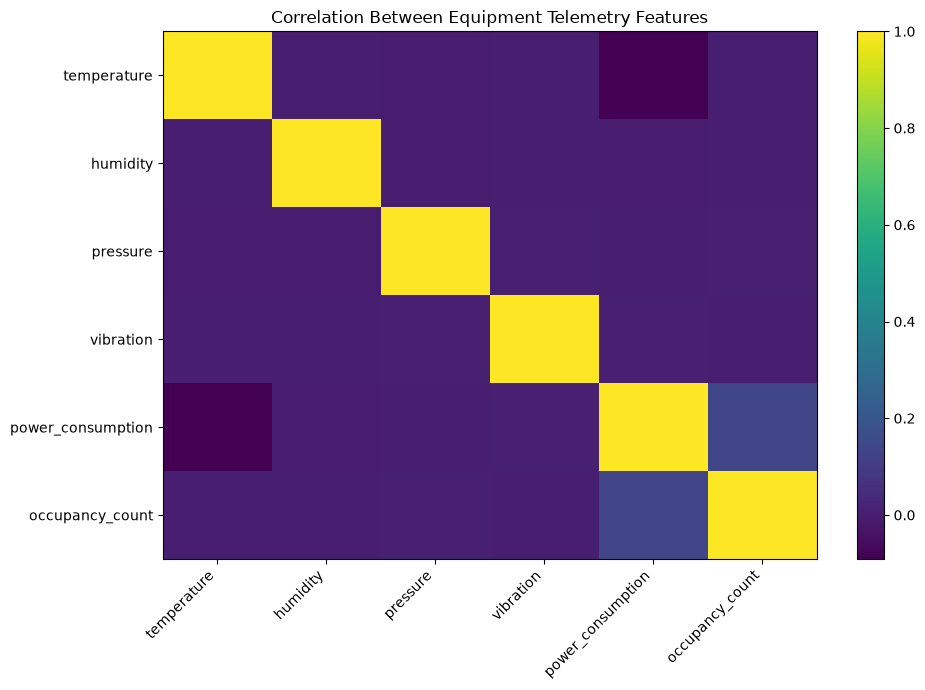

In [5]:
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(anomaly_features)),
    anomaly_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(anomaly_features)),
    anomaly_features
)

plt.title("Correlation Between Equipment Telemetry Features")

plt.tight_layout()

plt.show()

In [6]:
#table for isolation forest
from sklearn.ensemble import IsolationForest

X_anomaly = anomaly_df[
    anomaly_features
].copy()

print("X anomaly shape:", X_anomaly.shape)

X anomaly shape: (60480, 6)


In [7]:
#train isolation forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_anomaly)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [8]:
#generate anomaly predictions
anomaly_df["Anomaly_Label"] = (
    iso_forest.predict(X_anomaly)
)

In [9]:
anomaly_df["Is_Anomaly"] = (
    anomaly_df["Anomaly_Label"] == -1
).astype(int)

In [10]:
#generate anomaly score
anomaly_df["Anomaly_Score"] = (
    -iso_forest.score_samples(X_anomaly)
)

print(
    anomaly_df[
        [
            "asset_id",
            "timestamp",
            "Anomaly_Score",
            "Is_Anomaly"
        ]
    ].head(20)
)

    asset_id            timestamp  Anomaly_Score  Is_Anomaly
0   B1_CH_01  2025-01-01 00:00:00       0.538528           0
1   B1_CH_01  2025-01-01 01:00:00       0.469220           0
2   B1_CH_01  2025-01-01 02:00:00       0.510811           0
3   B1_CH_01  2025-01-01 03:00:00       0.472660           0
4   B1_CH_01  2025-01-01 04:00:00       0.479343           0
5   B1_CH_01  2025-01-01 05:00:00       0.442765           0
6   B1_CH_01  2025-01-01 06:00:00       0.510887           0
7   B1_CH_01  2025-01-01 07:00:00       0.472451           0
8   B1_CH_01  2025-01-01 08:00:00       0.462460           0
9   B1_CH_01  2025-01-01 09:00:00       0.446972           0
10  B1_CH_01  2025-01-01 10:00:00       0.462584           0
11  B1_CH_01  2025-01-01 11:00:00       0.496339           0
12  B1_CH_01  2025-01-01 12:00:00       0.459396           0
13  B1_CH_01  2025-01-01 13:00:00       0.483469           0
14  B1_CH_01  2025-01-01 14:00:00       0.447507           0
15  B1_CH_01  2025-01-01

In [11]:
#anomalies were detected
total_anomalies = anomaly_df[
    "Is_Anomaly"
].sum()

total_records = len(anomaly_df)

anomaly_percentage = (
    total_anomalies / total_records
) * 100

print("Total records      :", total_records)
print("Total anomalies    :", total_anomalies)
print(
    "Anomaly percentage :",
    round(anomaly_percentage, 2),
    "%"
)

Total records      : 60480
Total anomalies    : 605
Anomaly percentage : 1.0 %


In [12]:
#view the detected anomalies
identified_anomalies = anomaly_df[
    anomaly_df["Is_Anomaly"] == 1
].copy()

identified_anomalies = identified_anomalies.sort_values(
    "Anomaly_Score",
    ascending=False
)

print(
    "Number of identified anomalies:",
    len(identified_anomalies)
)

identified_anomalies.head(20)

Number of identified anomalies: 605


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,Anomaly_Label,Is_Anomaly,Anomaly_Score
55391,2025-01-28 23:00:00,S3,B6,B6_AHU_02,33.45,36.37,105.62,2.57,14.35,5,-1,1,0.638826
50700,2025-01-13 12:00:00,S3,B6,B6_CH_01,16.28,70.80,103.78,3.03,10.97,32,-1,1,0.630243
14118,2025-02-18 06:00:00,S1,B2,B2_AHU_01_SEN,29.90,64.66,96.95,2.98,30.21,0,-1,1,0.628730
13629,2025-01-28 21:00:00,S1,B2,B2_AHU_01_SEN,29.44,74.48,97.95,2.43,25.55,0,-1,1,0.627650
53583,2025-01-13 15:00:00,S3,B6,B6_AHU_01_SEN,18.98,45.20,97.93,0.26,88.39,69,-1,1,0.627315
55213,2025-01-21 13:00:00,S3,B6,B6_AHU_02,32.31,73.24,98.34,1.67,22.84,66,-1,1,0.626203
55322,2025-01-26 02:00:00,S3,B6,B6_AHU_02,31.25,36.69,98.54,2.94,13.49,2,-1,1,0.624994
50417,2025-01-01 17:00:00,S3,B6,B6_CH_01,16.73,44.61,97.51,0.63,16.74,62,-1,1,0.624270
54226,2025-02-09 10:00:00,S3,B6,B6_AHU_01_SEN,16.64,47.52,98.05,0.01,94.05,54,-1,1,0.623803
36294,2025-01-13 06:00:00,S2,B4,B4_AHU_02_SEN,29.74,74.52,99.05,3.03,56.24,0,-1,1,0.623346


In [13]:
#find which assets have the most anomalies
asset_anomaly_summary = (
    identified_anomalies
    .groupby(
        ["asset_id", "building_id", "site_id"]
    )
    .agg(
        Anomaly_Count=(
            "Is_Anomaly",
            "count"
        ),
        Max_Anomaly_Score=(
            "Anomaly_Score",
            "max"
        ),
        Avg_Anomaly_Score=(
            "Anomaly_Score",
            "mean"
        )
    )
    .reset_index()
)

asset_anomaly_summary = (
    asset_anomaly_summary
    .sort_values(
        "Anomaly_Count",
        ascending=False
    )
)

asset_anomaly_summary.head(20)

,asset_id,building_id,site_id,Anomaly_Count,Max_Anomaly_Score,Avg_Anomaly_Score
18,B3_CH_01,B3,S2,74,0.622805,0.591926
37,B6_AHU_02,B6,S3,51,0.638826,0.594507
39,B6_CH_01,B6,S3,42,0.630243,0.589342
27,B4_PUMP_01,B4,S2,28,0.618356,0.589781
36,B6_AHU_01_SEN,B6,S3,27,0.627315,0.593655
32,B5_CH_01,B5,S3,27,0.605136,0.585761
11,B2_CH_01,B2,S1,23,0.620591,0.592204
26,B4_METER_01,B4,S2,23,0.614844,0.590191
41,B6_PUMP_01,B6,S3,22,0.621950,0.591915
24,B4_AHU_02_SEN,B4,S2,21,0.623346,0.590595


In [14]:
#analyze anomaly type
for feature in anomaly_features:

    mean_value = anomaly_df[feature].mean()
    std_value = anomaly_df[feature].std()

    upper_limit = mean_value + 3 * std_value
    lower_limit = mean_value - 3 * std_value

    anomaly_df[f"{feature}_Anomaly"] = (
        (anomaly_df[feature] > upper_limit) |
        (anomaly_df[feature] < lower_limit)
    )

    print(
        feature,
        "Upper:", round(upper_limit, 2),
        "Lower:", round(lower_limit, 2)
    )

temperature Upper: 34.12 Lower: 12.31
humidity Upper: 89.58 Lower: 20.44
pressure Upper: 105.8 Lower: 96.8
vibration Upper: 3.28 Lower: -0.28
power_consumption Upper: 120.26 Lower: -20.8
occupancy_count Upper: 91.27 Lower: -35.15


In [15]:
#count anomaly types
anomaly_type_counts = {}

for feature in anomaly_features:

    column = f"{feature}_Anomaly"

    anomaly_type_counts[feature] = (
        anomaly_df[column].sum()
    )

anomaly_type_counts = pd.Series(
    anomaly_type_counts
).sort_values(
    ascending=False
)

print(anomaly_type_counts)

pressure             165
vibration             89
temperature           14
humidity               0
power_consumption      0
occupancy_count        0
dtype: int64


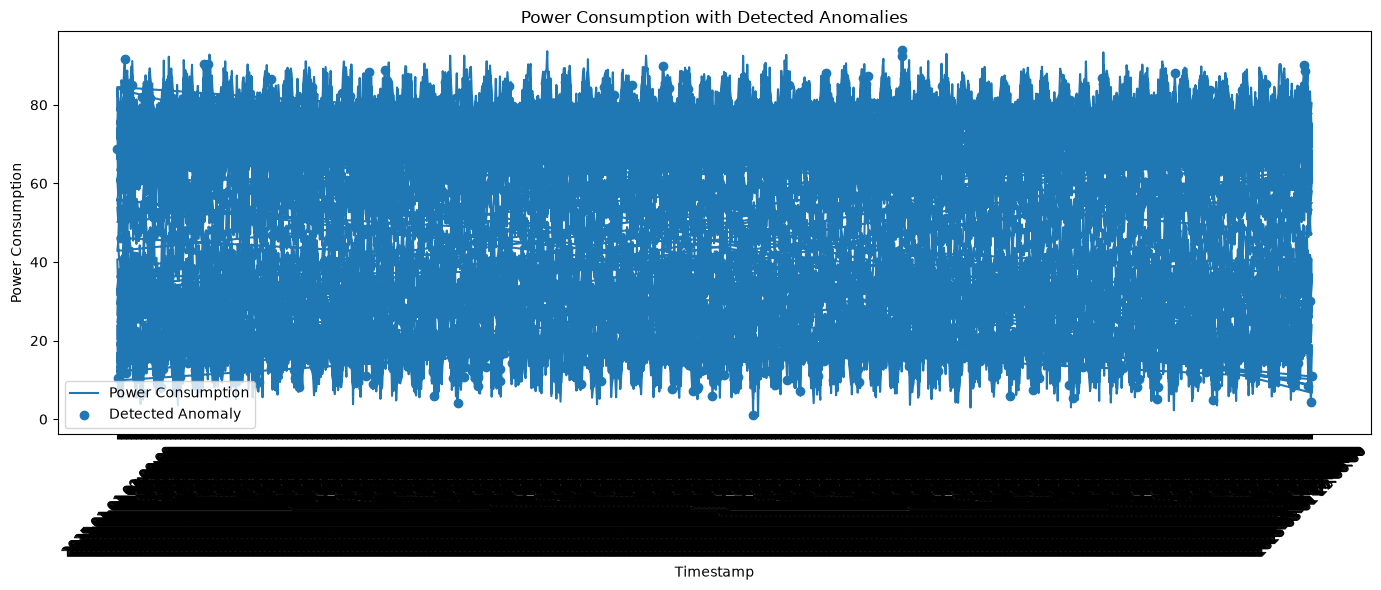

In [16]:
#visualize power anomalies
plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["timestamp"],
    anomaly_df["power_consumption"],
    label="Power Consumption"
)

anomaly_points = anomaly_df[
    anomaly_df["Is_Anomaly"] == 1
]

plt.scatter(
    anomaly_points["timestamp"],
    anomaly_points["power_consumption"],
    label="Detected Anomaly"
)

plt.xlabel("Timestamp")
plt.ylabel("Power Consumption")

plt.title(
    "Power Consumption with Detected Anomalies"
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

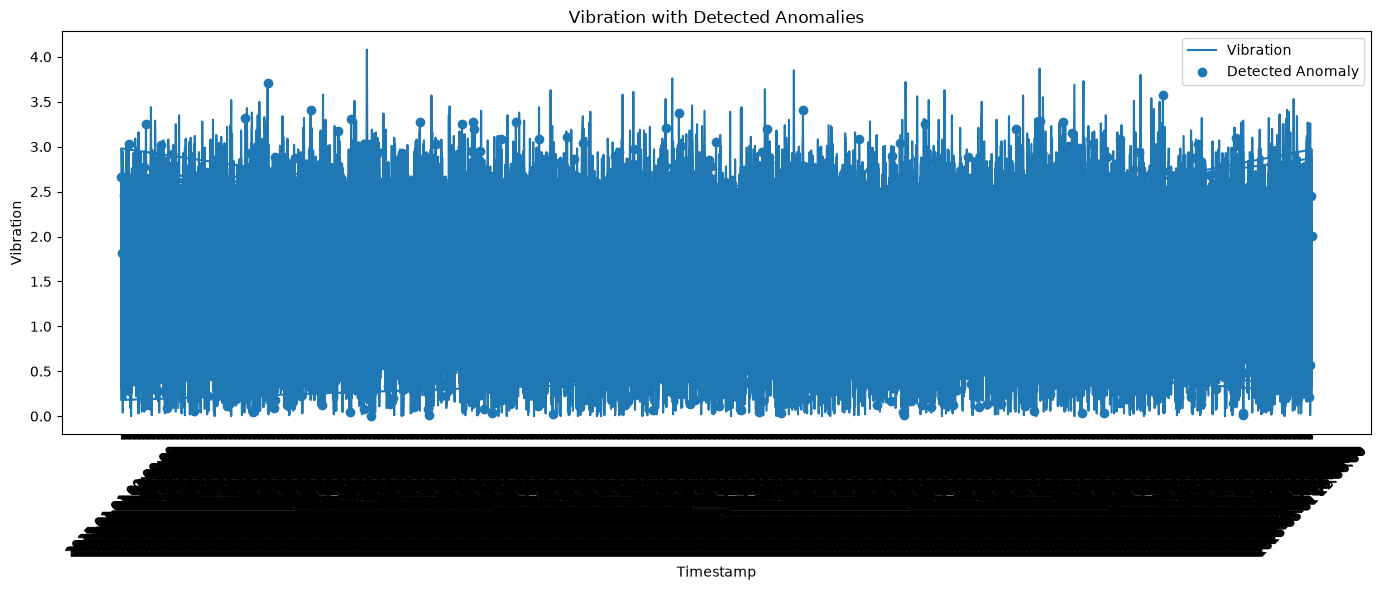

In [17]:
#visulize vibration anomalies
plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["timestamp"],
    anomaly_df["vibration"],
    label="Vibration"
)

vibration_anomalies = anomaly_df[
    anomaly_df["Is_Anomaly"] == 1
]

plt.scatter(
    vibration_anomalies["timestamp"],
    vibration_anomalies["vibration"],
    label="Detected Anomaly"
)

plt.xlabel("Timestamp")
plt.ylabel("Vibration")

plt.title(
    "Vibration with Detected Anomalies"
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

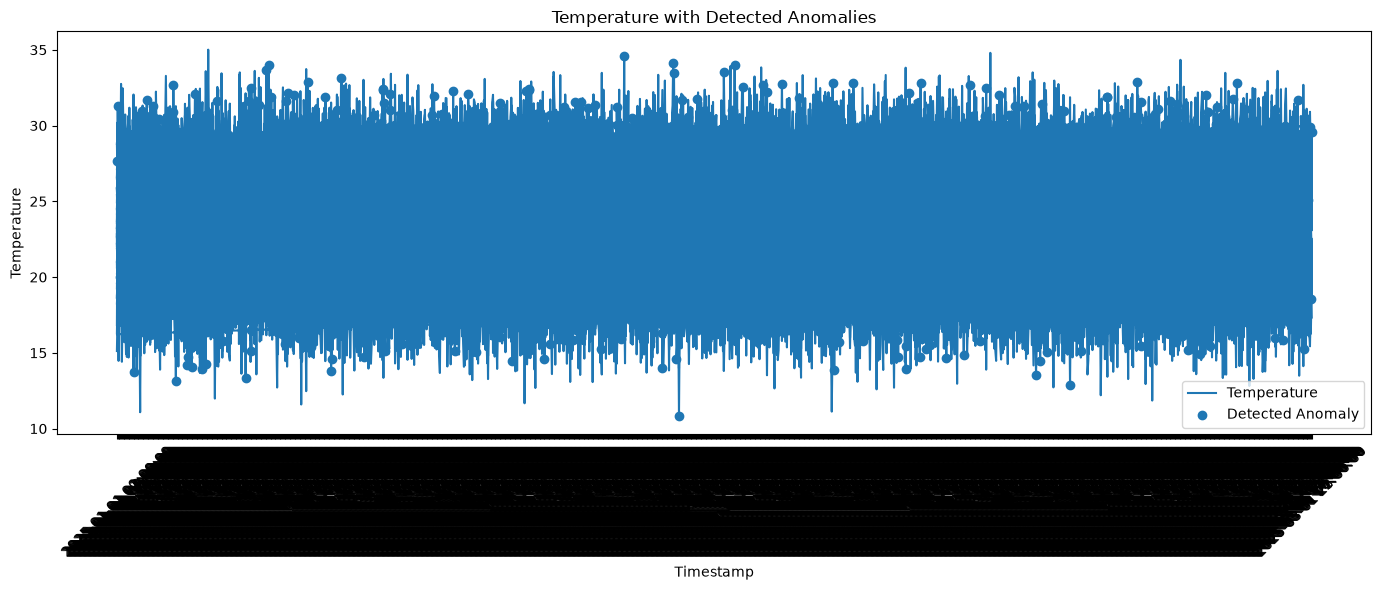

In [18]:
#visualize temp anomalies
plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["timestamp"],
    anomaly_df["temperature"],
    label="Temperature"
)

temperature_anomalies = anomaly_df[
    anomaly_df["Is_Anomaly"] == 1
]

plt.scatter(
    temperature_anomalies["timestamp"],
    temperature_anomalies["temperature"],
    label="Detected Anomaly"
)

plt.xlabel("Timestamp")
plt.ylabel("Temperature")

plt.title(
    "Temperature with Detected Anomalies"
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

In [19]:
#final anomaly output
final_anomaly_output = identified_anomalies[
    [
        "timestamp",
        "site_id",
        "building_id",
        "asset_id",
        "temperature",
        "humidity",
        "pressure",
        "vibration",
        "power_consumption",
        "occupancy_count",
        "Anomaly_Score",
        "Is_Anomaly"
    ]
].copy()

final_anomaly_output.head(20)

,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,Anomaly_Score,Is_Anomaly
55391,2025-01-28 23:00:00,S3,B6,B6_AHU_02,33.45,36.37,105.62,2.57,14.35,5,0.638826,1
50700,2025-01-13 12:00:00,S3,B6,B6_CH_01,16.28,70.80,103.78,3.03,10.97,32,0.630243,1
14118,2025-02-18 06:00:00,S1,B2,B2_AHU_01_SEN,29.90,64.66,96.95,2.98,30.21,0,0.628730,1
13629,2025-01-28 21:00:00,S1,B2,B2_AHU_01_SEN,29.44,74.48,97.95,2.43,25.55,0,0.627650,1
53583,2025-01-13 15:00:00,S3,B6,B6_AHU_01_SEN,18.98,45.20,97.93,0.26,88.39,69,0.627315,1
55213,2025-01-21 13:00:00,S3,B6,B6_AHU_02,32.31,73.24,98.34,1.67,22.84,66,0.626203,1
55322,2025-01-26 02:00:00,S3,B6,B6_AHU_02,31.25,36.69,98.54,2.94,13.49,2,0.624994,1
50417,2025-01-01 17:00:00,S3,B6,B6_CH_01,16.73,44.61,97.51,0.63,16.74,62,0.624270,1
54226,2025-02-09 10:00:00,S3,B6,B6_AHU_01_SEN,16.64,47.52,98.05,0.01,94.05,54,0.623803,1
36294,2025-01-13 06:00:00,S2,B4,B4_AHU_02_SEN,29.74,74.52,99.05,3.03,56.24,0,0.623346,1


In [20]:
#save the identified anomalies
final_anomaly_output.to_csv(
    "identified_equipment_anomalies.csv",
    index=False
)

asset_anomaly_summary.to_csv(
    "asset_anomaly_summary.csv",
    index=False
)

print("Anomaly files saved successfully.")

Anomaly files saved successfully.


Summary

An anomaly detection framework was developed using Isolation Forest to identify abnormal equipment behavior across temperature, humidity, pressure, vibration, power consumption, and occupancy related telemetry.

Statistical thresholding using the three-standard-deviation rule was additionally used to identify unusual values in individual sensor variables. Anomaly scores were generated to rank observations based on the severity of abnormal behavior.

The detected anomalies were analyzed at both the observation and asset levels to identify equipment experiencing abnormal behavior more frequently. Visualizations were created to examine abnormal patterns in power consumption, vibration, and temperature.

Business Recommendations
- Prioritize assets with frequent or high-severity anomalies for inspection.
- Investigate excessive vibration as a potential indicator of mechanical or equipment degradation.
- Investigate unusual power consumption for possible equipment inefficiency or abnormal operation.
- Monitor abnormal temperature patterns for potential overheating or equipment issues.
- Combine anomaly detection results with the predictive-maintenance model to improve maintenance prioritization.
- Continuously monitor anomaly scores to identify abnormal equipment behavior at an early stage.